# Question from Sells team PM
### Is there any relation between preparation time and sales?

In [1]:
import pandas as pd

df_products = pd.read_csv('../data/BaSalam.products.csv', nrows=100000)


/tmp/ipykernel_20726/3422545124.py:3: DtypeWarning: Columns (0: mainAttribute, 1: promotions) have mixed types. Specify dtype option on import or set low_memory=False.
  df_products = pd.read_csv('../data/BaSalam.products.csv', nrows=100000)


In [2]:
# removing unnecessary columns
df_products = df_products.drop(columns=['promotions','video_ORIGINAL','published','mainAttribute','IsSaleable','IsAvailable','isFreeShipping','vendor_owner_id','vendor_owner_city','vendor_status_title','vendor_status_id','vendor_id','vendor_score','vendor_has_delivery','vendor_provinceId','vendor_cityId','vendor_freeShippingToSameCity','vendor_freeShippingToIran','vendor_statusId','vendor_identifier','vendor_name','navigation_id','new_categoryId','has_variation','categoryId','weight','rating_signals','rating_count','rating_average','photo_SMALL','photo_MEDIUM','status_id'])

In [3]:
df_products

,_id,_score,sales_count_week,name,price,status_title,stock,primaryPrice,preparationDays,has_delivery,categoryTitle
0,9873883,468.75000,14,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000,در دسترس,746,6000000,5,True,میوه تازه
1,21808,466.66666,13,روغن زیتون فدک 1 لیتری مزرعه ارگانیک فدک سید ا...,6600000,در دسترس,4,0,1,True,روغن‌های خوراکی
2,10215970,464.28570,12,عناب درجه یک بیرجند یک کیلویی. تضمین کیفیت و ...,1360000,در دسترس,813,1650000,5,True,میوه تازه
3,11061637,461.53845,11,هل سبز اکبر بنفش50گرمی. سبز ودرشت وبسیار معطر,1054000,در دسترس,1708,1250000,5,True,ادویه
4,10843522,461.53845,11,زرشک دانه اناری اعلا 1402(یک کیلویی).محصول تضم...,1830000,در دسترس,1509,2100000,5,True,میوه تازه
...,...,...,...,...,...,...,...,...,...,...,...
99995,10702363,0.00000,0,کاغذ دیواری گوچی 55001,2890000,در دسترس,100,3400000,1,True,پوستر و کاغذ دیواری
99996,10707207,0.00000,0,کاغذ دیواری گوچی 55015,2890000,در دسترس,300,3400000,1,True,پوستر و کاغذ دیواری
99997,10707576,0.00000,0,کاغذ دیواری گوچی 55033,2890000,در دسترس,300,3400000,1,True,پوستر و کاغذ دیواری
99998,10707757,0.00000,0,کاغذ دیواری گوچی 55039,2890000,در دسترس,500,3400000,1,True,پوستر و کاغذ دیواری


In [4]:
df_products['daily_sale'] = df_products['sales_count_week'] / 7
df_products

,_id,_score,sales_count_week,name,price,status_title,stock,primaryPrice,preparationDays,has_delivery,categoryTitle,daily_sale
0,9873883,468.75000,14,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000,در دسترس,746,6000000,5,True,میوه تازه,2.000000
1,21808,466.66666,13,روغن زیتون فدک 1 لیتری مزرعه ارگانیک فدک سید ا...,6600000,در دسترس,4,0,1,True,روغن‌های خوراکی,1.857143
2,10215970,464.28570,12,عناب درجه یک بیرجند یک کیلویی. تضمین کیفیت و ...,1360000,در دسترس,813,1650000,5,True,میوه تازه,1.714286
3,11061637,461.53845,11,هل سبز اکبر بنفش50گرمی. سبز ودرشت وبسیار معطر,1054000,در دسترس,1708,1250000,5,True,ادویه,1.571429
4,10843522,461.53845,11,زرشک دانه اناری اعلا 1402(یک کیلویی).محصول تضم...,1830000,در دسترس,1509,2100000,5,True,میوه تازه,1.571429
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10702363,0.00000,0,کاغذ دیواری گوچی 55001,2890000,در دسترس,100,3400000,1,True,پوستر و کاغذ دیواری,0.000000
99996,10707207,0.00000,0,کاغذ دیواری گوچی 55015,2890000,در دسترس,300,3400000,1,True,پوستر و کاغذ دیواری,0.000000
99997,10707576,0.00000,0,کاغذ دیواری گوچی 55033,2890000,در دسترس,300,3400000,1,True,پوستر و کاغذ دیواری,0.000000
99998,10707757,0.00000,0,کاغذ دیواری گوچی 55039,2890000,در دسترس,500,3400000,1,True,پوستر و کاغذ دیواری,0.000000


In [7]:
df_products['preparationDays'].corr(df_products['daily_sale'], method='spearman')

np.float64(-0.003132625303295468)

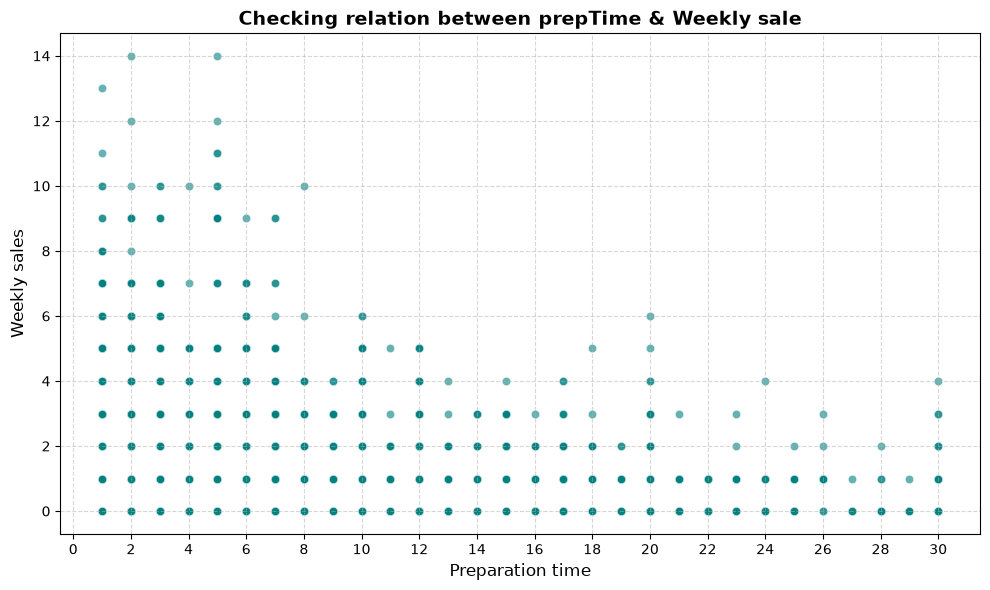

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_products,
    x='preparationDays',
    y='sales_count_week',
    alpha=0.6,
    color='teal'
)

plt.title('Checking relation between prepTime & Weekly sale', fontsize=14, fontweight='bold')
plt.xlabel('Preparation time', fontsize=12)
plt.ylabel('Weekly sales', fontsize=12)

plt.xticks(range(0, 31, 2))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
 

plt.show()

## Answer to the PM:
### There is only a very weak relationship between preparation time and weekly sales. Products with very long preparation times (20+ days) sell slightly less, but the difference is small. Most products sell less than one unit per week regardless of preparation time.